<a href="https://colab.research.google.com/github/at-ki10/-Telco-Churn-XAI/blob/main/Telco_Churn_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# 1. رابط البيانات الخام
url = "https://raw.githubusercontent.com/windythalia/Telco-Customer-Churn.csv/refs/heads/main/Telco-Customer-Churn.csv"

# 2. قراءة البيانات في دالة DataFrame
df = pd.read_csv(url)

# 3. عرض أول 5 صفوف للتأكد من نجاح التحميل
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,F,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. إزالة عمود الهوية لأنه غير مفيد للنموذج
df = df.drop(columns=['customerID'])

# 2. تحويل عمود TotalCharges إلى أرقام
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. عرض شكل البيانات النهائي
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7038 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7040 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [4]:
# 1. تعبئة القيم الفارغة في TotalCharges بالصفر
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. تحويل جميع النصوص إلى أرقام (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. عرض شكل البيانات الجديد وأول 5 صفوف
print("شكل البيانات الجديد (صفوف، أعمدة):", df_encoded.shape)
df_encoded.head()

شكل البيانات الجديد (صفوف، أعمدة): (7043, 33)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_M,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1.0,29.85,29.85,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34.0,56.95,1889.50,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
2,0,2.0,53.85,108.15,False,False,True,False,False,True,...,False,False,False,False,False,True,False,False,True,True
3,0,45.0,42.30,1840.75,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2.0,70.70,151.65,True,False,False,False,False,True,...,False,False,False,False,False,True,False,True,False,True


In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. تحديد المتغيرات (X هي الخصائص، y هي النتيجة المطلوب تنبؤها)
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

# 2. تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. إنشاء وتدريب نموذج XGBoost
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. التوقع على بيانات الاختبار وتقييم الدقة
y_pred = model.predict(X_test)

print(f"--- دقة النموذج الإجمالية (Accuracy): {accuracy_score(y_test, y_pred):.2%} ---\n")
print("--- تقرير التقييم التفصيلي (Classification Report) ---")
print(classification_report(y_test, y_pred))

--- دقة النموذج الإجمالية (Accuracy): 77.86% ---

--- تقرير التقييم التفصيلي (Classification Report) ---
              precision    recall  f1-score   support

       False       0.83      0.87      0.85      1035
        True       0.60      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



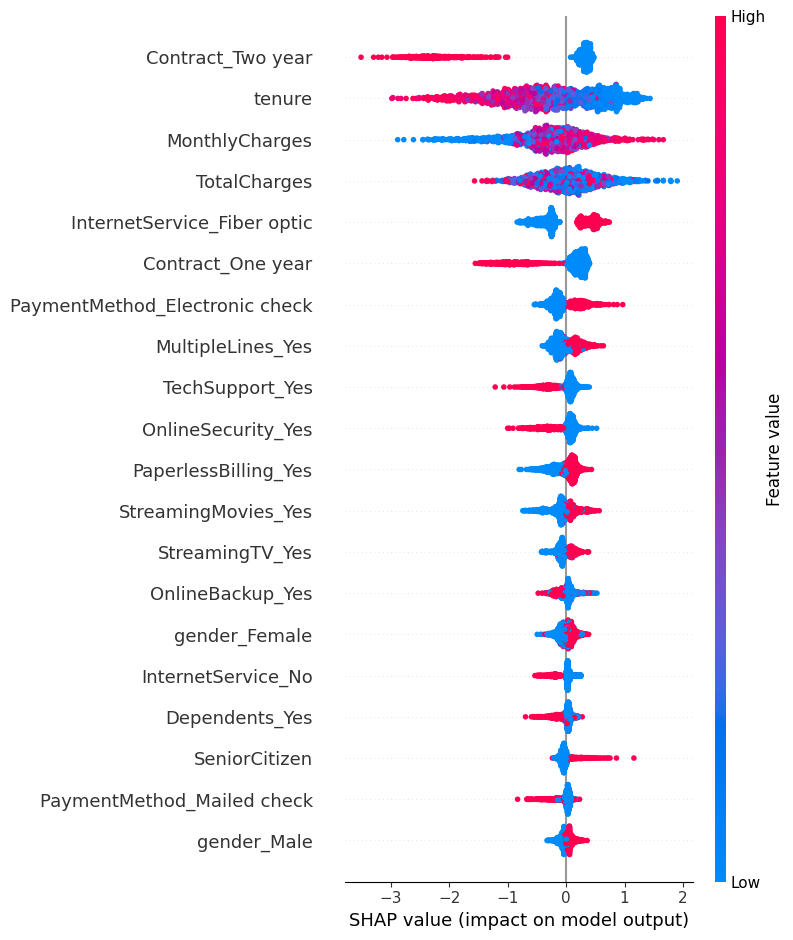

In [6]:
# 1. تثبيت مكتبة SHAP
!pip install shap -q

import shap

# 2. إنشاء المفسر الخاط بـ XGBoost
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 3. رسم مخطط ملخص أسباب التسرب (Summary Plot)
shap.summary_plot(shap_values, X_test)

In [18]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# 1. تحويل البيانات إلى مصفوفات NumPy صافية لتفادي أخطاء Pandas و Scipy
X_train_np = X_train.astype(float).to_numpy()
X_test_np = X_test.astype(float).to_numpy()

# 2. إنشاء المفسر مع إيقاف التجزئة المستمرة لتجنب تعارض scipy.stats
explainer_lime = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X_train.columns.tolist(),
    class_names=['Stay', 'Churn'],
    mode='classification',
    discretize_continuous=False
)

# 3. تفسير حالة العميل الأول (السطر رقم 0)
exp = explainer_lime.explain_instance(
    data_row=X_test_np[0],
    predict_fn=model.predict_proba,
    num_features=10
)

# 4. عرض النتيجة
exp.show_in_notebook(show_table=True)

In [19]:
# استعراض بياناته كاملة بالنصوص الأصلية من الجدول الأول
df.iloc[[X_test.index[0]]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,Male,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,No
